# 08 - 3D Forward Model and Depth Reconstruction

The earlier notebooks treated the scene as a single 2D object plane:

$$ b = A x + n $$

DiffuserCam's key 3D idea is that different depths produce different PSFs. A single sensor image can therefore contain depth information, because each depth layer is encoded differently:

$$ b = \sum_{z=1}^{Z} A_z x_z + n $$

This notebook builds the first robust 3D simulation:

1. Derive the 3D forward model.
2. Generate depth-dependent synthetic PSFs.
3. Build a layered 3D scene with known ground truth.
4. Simulate one sensor measurement from all depth layers.
5. Reconstruct the volume with projected FISTA.
6. Evaluate lateral recovery, depth recovery, depth leakage, and robustness to noise/model mismatch.


## 1. Mathematical Model

For incoherent imaging, intensities add. If the object is a 3D intensity distribution \(x(r,s,z)\), the sensor image can be written as:

$$
b(u,v)
=
\int_z \int_r \int_s
h_z(u-r, v-s)\, x(r,s,z)\, dr\, ds\, dz
+ n(u,v)
$$

After discretizing depth into \(Z\) planes:

$$
b = \sum_{k=1}^{Z} h_k * x_k + n
$$

or in matrix form:

$$
b = A_1 x_1 + A_2 x_2 + \cdots + A_Z x_Z + n
$$

Stack all depth planes into one vector:

$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_Z
\end{bmatrix},
\qquad
A =
\begin{bmatrix}
A_1 & A_2 & \cdots & A_Z
\end{bmatrix}
$$

Then the 3D problem has the familiar form:

$$
b = A x + n
$$

The difference is that \(x\) is now a volume, while \(b\) is still one 2D sensor image.


## 2. Why This Is Hard

The sensor image has only \(M \times N\) pixels, but the unknown volume has \(Z \times M \times N\) voxels. That means the problem is underdetermined unless the depth PSFs are sufficiently different and we add useful priors.

In this first 3D notebook, we use three simple priors:

- **nonnegativity:** light intensity cannot be negative,
- **L2 regularization:** discourages unbounded energy in the volume,
- **early stopping:** avoids overfitting noise.

Later we can add 3D TV, depth sparsity, support constraints, and PyTorch/GPU acceleration.


## Setup


In [1]:
from pathlib import Path
import sys
import json
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import PaddedLinearConvolution, psnr, residual_relative_l2, ssim

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '08_3d_forward_model_depth_reconstruction'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#263238',
        'axes.labelcolor': '#263238',
        'axes.titleweight': 'bold',
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.color': '#263238',
        'ytick.color': '#263238',
        'grid.color': '#d9e0e3',
        'grid.linewidth': 0.8,
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.facecolor': 'white',
        'font.size': 10,
        'figure.max_open_warning': 80,
    }
)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

In [2]:
def save_figure(fig, path: Path):
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return fig


def normalize_sum(image: np.ndarray) -> np.ndarray:
    image = np.maximum(np.asarray(image, dtype=np.float64), 0.0)
    return image / max(float(np.sum(image)), 1e-12)


def display_scale(image: np.ndarray, percentiles=(1, 99.7)) -> np.ndarray:
    image = np.asarray(image, dtype=np.float64)
    low, high = np.percentile(image, percentiles)
    if high <= low:
        return np.zeros_like(image)
    return np.clip((image - low) / (high - low), 0.0, 1.0)


def plot_image_grid(items, path: Path, columns: int = 3, title: str | None = None):
    rows = int(np.ceil(len(items) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4.0 * columns, 3.4 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (label, image) in zip(axes, items):
        ax.imshow(display_scale(image), cmap='gray', vmin=0, vmax=1)
        ax.set_title(label)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(items):]:
        ax.axis('off')
    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight='bold')
    return save_figure(fig, path)


def add_panel_note(ax, text: str, y: float = 0.05):
    ax.text(
        0.03,
        y,
        text,
        transform=ax.transAxes,
        fontsize=8.7,
        va='bottom',
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '#cfd8dc', 'alpha': 0.92},
    )


def normalized_mse(reference: np.ndarray, estimate: np.ndarray) -> float:
    diff = np.asarray(reference) - np.asarray(estimate)
    return float(np.sum(diff * diff) / max(np.sum(reference * reference), 1e-12))


def volume_psnr(reference: np.ndarray, estimate: np.ndarray) -> float:
    return psnr(reference.ravel(), np.clip(estimate, 0.0, 1.0).ravel(), data_range=1.0)

## 3. Synthetic Depth-Dependent PSFs

In a real DiffuserCam, each depth has a measured PSF:

$$
h_1, h_2, \ldots, h_Z
$$

We simulate this by creating several different caustic-like PSFs. These are not exact wave-optics PSFs; they are deliberately simple synthetic calibration patterns that let us test the inverse problem.

The important property is that the PSFs are **different across depth**. If two depths have identical PSFs, the sensor cannot distinguish them.


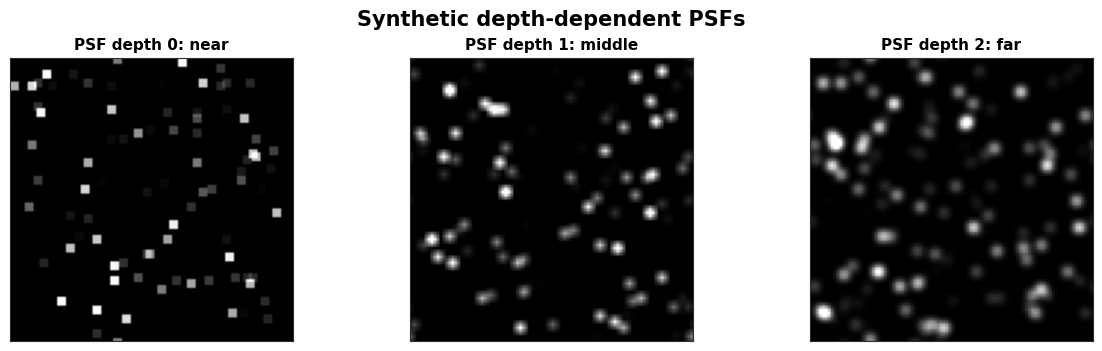

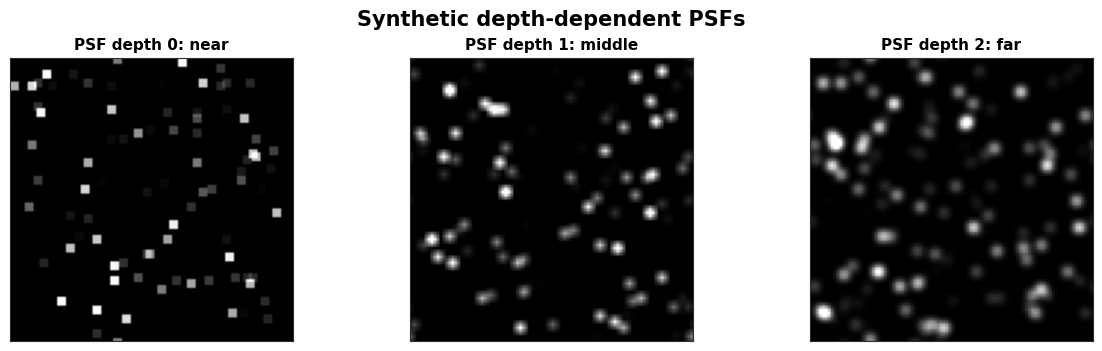

In [3]:
def circular_box_blur(image: np.ndarray, rounds: int) -> np.ndarray:
    blurred = np.asarray(image, dtype=np.float64)
    for _ in range(rounds):
        blurred = (
            blurred
            + np.roll(blurred, 1, axis=0)
            + np.roll(blurred, -1, axis=0)
            + np.roll(blurred, 1, axis=1)
            + np.roll(blurred, -1, axis=1)
            + np.roll(np.roll(blurred, 1, axis=0), 1, axis=1)
            + np.roll(np.roll(blurred, 1, axis=0), -1, axis=1)
            + np.roll(np.roll(blurred, -1, axis=0), 1, axis=1)
            + np.roll(np.roll(blurred, -1, axis=0), -1, axis=1)
        ) / 9.0
    return blurred


def make_depth_psf(size: int, seed: int, spot_count: int, blur_rounds: int, roll: tuple[int, int]) -> np.ndarray:
    rng = np.random.default_rng(seed)
    psf = np.zeros((size, size), dtype=np.float64)
    rows = rng.integers(0, size, size=spot_count)
    cols = rng.integers(0, size, size=spot_count)
    weights = rng.random(spot_count) ** 2
    psf[rows, cols] += weights
    psf = circular_box_blur(psf, blur_rounds)
    psf = np.roll(np.roll(psf, roll[0], axis=0), roll[1], axis=1)
    psf += 1e-6 * np.max(psf)
    return normalize_sum(psf)


image_size = 96
depth_labels = ['near', 'middle', 'far']
psfs = [
    make_depth_psf(image_size, seed=10, spot_count=95, blur_rounds=1, roll=(-5, 3)),
    make_depth_psf(image_size, seed=22, spot_count=120, blur_rounds=2, roll=(0, 0)),
    make_depth_psf(image_size, seed=37, spot_count=150, blur_rounds=3, roll=(5, -4)),
]
operators = [PaddedLinearConvolution(psf) for psf in psfs]

plot_image_grid(
    [(f'PSF depth {index}: {label}', psf) for index, (label, psf) in enumerate(zip(depth_labels, psfs))],
    RESULT_DIR / '01_depth_dependent_psfs.png',
    columns=3,
    title='Synthetic depth-dependent PSFs',
)

## 4. Build a Layered 3D Scene

We create a volume with three depth planes. Each plane contains a different object at a mostly different lateral location. This makes depth evaluation easier because we know which pixels should belong to which depth.

The ground truth volume is:

$$
x =
\{x_{\text{near}}, x_{\text{middle}}, x_{\text{far}}\}
$$


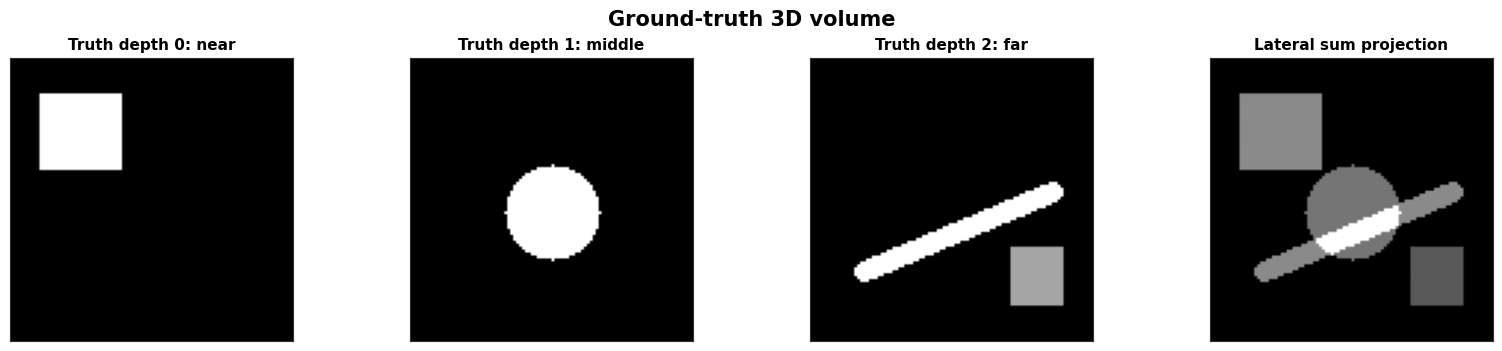

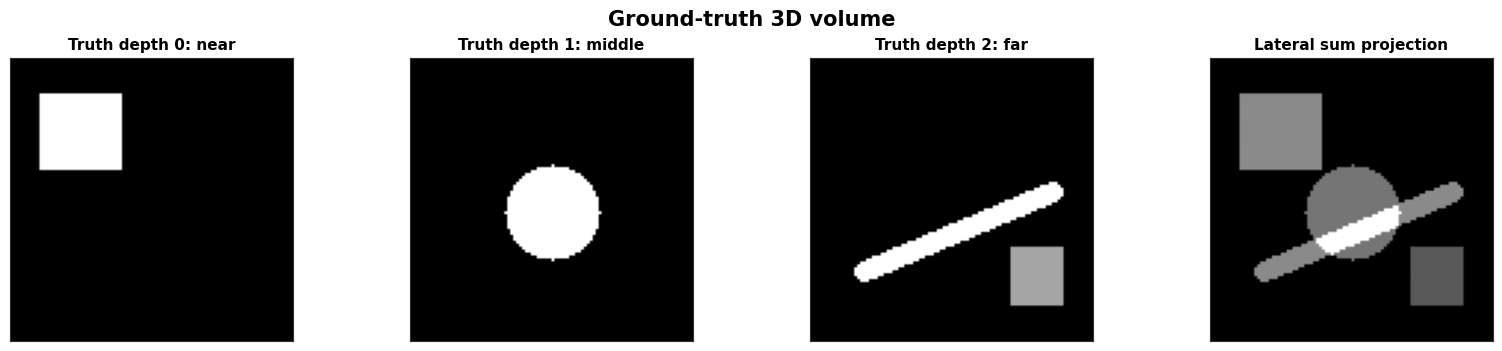

In [4]:
def add_rectangle(image: np.ndarray, row0: int, row1: int, col0: int, col1: int, value: float):
    image[row0:row1, col0:col1] = value


def add_disk(image: np.ndarray, center: tuple[int, int], radius: int, value: float):
    yy, xx = np.mgrid[: image.shape[0], : image.shape[1]]
    mask = (yy - center[0]) ** 2 + (xx - center[1]) ** 2 <= radius**2
    image[mask] = value


def add_line(image: np.ndarray, row_start: int, col_start: int, row_end: int, col_end: int, width: int, value: float):
    yy, xx = np.mgrid[: image.shape[0], : image.shape[1]]
    a = np.array([row_start, col_start], dtype=float)
    b = np.array([row_end, col_end], dtype=float)
    p = np.stack([yy, xx], axis=-1).astype(float)
    ab = b - a
    t = np.clip(np.sum((p - a) * ab, axis=-1) / max(float(np.dot(ab, ab)), 1e-12), 0.0, 1.0)
    nearest = a + t[..., None] * ab
    distance = np.sqrt(np.sum((p - nearest) ** 2, axis=-1))
    image[distance <= width / 2] = value


truth_volume = np.zeros((len(depth_labels), image_size, image_size), dtype=np.float64)
add_rectangle(truth_volume[0], 12, 38, 10, 38, 1.0)
add_disk(truth_volume[1], center=(52, 48), radius=16, value=0.85)
add_line(truth_volume[2], 72, 18, 45, 82, width=7, value=1.0)
add_rectangle(truth_volume[2], 64, 84, 68, 86, 0.65)

depth_support_masks = truth_volume > 0.05
object_projection = np.sum(truth_volume, axis=0)

plot_image_grid(
    [(f'Truth depth {index}: {label}', truth_volume[index]) for index, label in enumerate(depth_labels)]
    + [('Lateral sum projection', object_projection)],
    RESULT_DIR / '02_truth_volume.png',
    columns=4,
    title='Ground-truth 3D volume',
)

## 5. 3D Forward Simulation

The simulated sensor image is the sum of the depth-specific measurements:

$$
b = A_1 x_1 + A_2 x_2 + A_3 x_3 + n
$$

The sensor does not receive a separate image per depth. It receives one multiplexed 2D measurement.


In [5]:
def forward_volume(operators: list[PaddedLinearConvolution], volume: np.ndarray) -> np.ndarray:
    measurement = np.zeros(operators[0].image_shape, dtype=np.float64)
    for operator, plane in zip(operators, volume):
        measurement += operator.forward(plane)
    return measurement


def add_gaussian_noise_by_snr(signal: np.ndarray, snr_db: float, seed: int = 0) -> tuple[np.ndarray, float]:
    rng = np.random.default_rng(seed)
    rms = float(np.sqrt(np.mean(signal * signal)))
    sigma = rms / (10.0 ** (snr_db / 20.0))
    noisy = signal + rng.normal(0.0, sigma, signal.shape)
    return np.maximum(noisy, 0.0), sigma


clean_measurement = forward_volume(operators, truth_volume)
measurement, noise_sigma = add_gaussian_noise_by_snr(clean_measurement, snr_db=35, seed=8)

forward_info = {
    'measurement_shape': measurement.shape,
    'snr_db': 35,
    'noise_sigma': noise_sigma,
    'clean_measurement_max': float(clean_measurement.max()),
    'noisy_measurement_max': float(measurement.max()),
}

forward_info

{'measurement_shape': (96, 96),
 'snr_db': 35,
 'noise_sigma': 0.003170543075018259,
 'clean_measurement_max': 0.37374289751063283,
 'noisy_measurement_max': 0.37337263065772025}

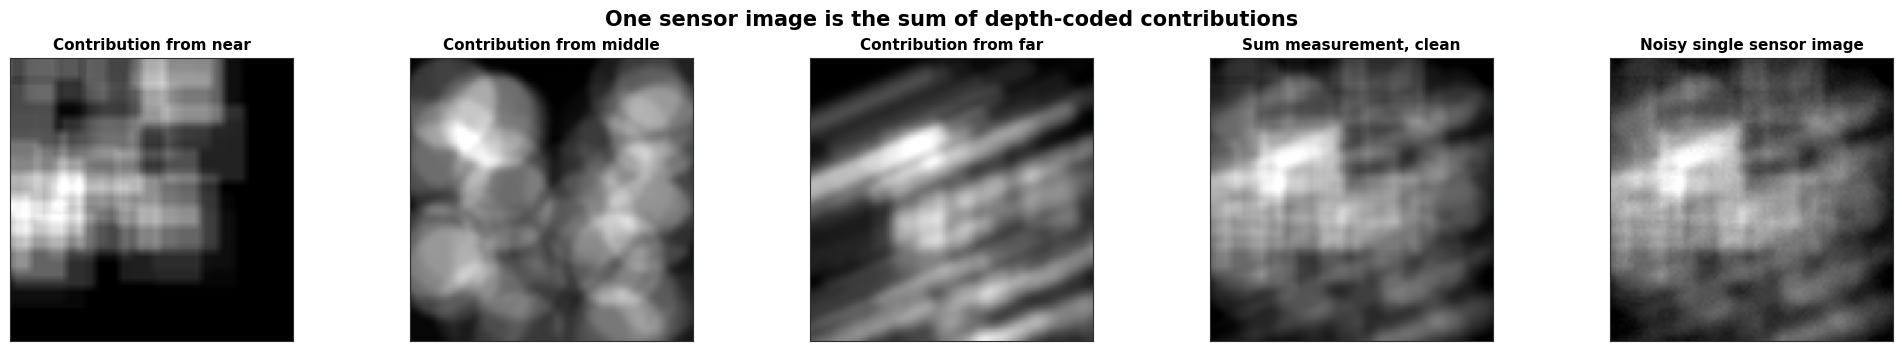

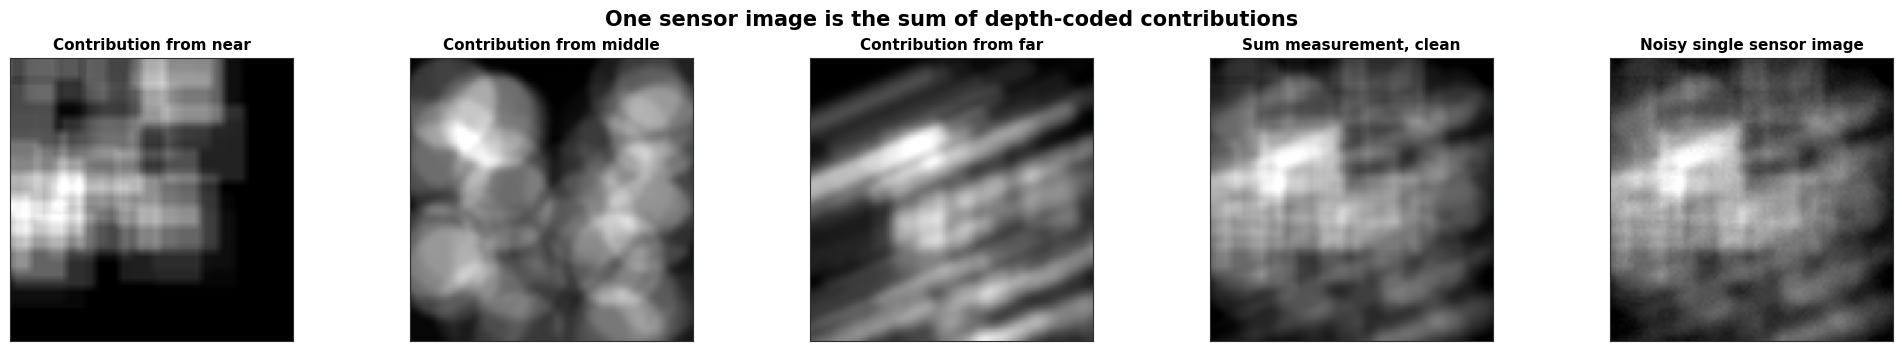

In [6]:
depth_measurements = [operator.forward(plane) for operator, plane in zip(operators, truth_volume)]
plot_image_grid(
    [(f'Contribution from {label}', image) for label, image in zip(depth_labels, depth_measurements)]
    + [('Sum measurement, clean', clean_measurement), ('Noisy single sensor image', measurement)],
    RESULT_DIR / '03_forward_measurement.png',
    columns=5,
    title='One sensor image is the sum of depth-coded contributions',
)

## 6. Reconstruction Objective

We reconstruct the volume by solving a nonnegative L2-regularized least-squares problem:

$$
\min_{x_1,\ldots,x_Z \ge 0}
\frac{1}{2}
\left\|
\sum_{k=1}^{Z} A_k x_k - b
\right\|_2^2
+
\frac{\lambda}{2}
\sum_{k=1}^{Z} \|x_k\|_2^2
$$

Let the residual be:

$$
r = \sum_{k=1}^{Z} A_k x_k - b
$$

Then the gradient with respect to depth plane \(x_k\) is:

$$
\nabla_{x_k}
=
A_k^T r + \lambda x_k
$$

This is the natural 3D extension of the 2D FISTA solver. Each iteration does:

1. forward project all depth planes,
2. compute one shared residual,
3. backproject that residual through each depth PSF,
4. take an accelerated projected-gradient step,
5. enforce nonnegativity.


In [7]:
@dataclass
class VolumeRecord:
    iteration: int
    objective: float
    relative_residual_l2: float
    volume_nmse: float
    volume_psnr_db: float
    projection_ssim: float
    depth_accuracy: float


@dataclass
class VolumeReconstruction:
    volume: np.ndarray
    history: list[VolumeRecord]
    step_size: float
    l2_regularization: float


def adjoint_volume(operators: list[PaddedLinearConvolution], residual: np.ndarray) -> np.ndarray:
    gradients = []
    for operator in operators:
        gradients.append(operator.crop(operator.adjoint_padded(residual)))
    return np.stack(gradients, axis=0)


def depth_winner_accuracy(truth: np.ndarray, estimate: np.ndarray, truth_threshold: float = 0.05) -> float:
    support = truth > truth_threshold * max(float(truth.max()), 1e-12)
    if not np.any(support):
        return 0.0
    truth_depth = np.argmax(truth, axis=0)
    estimate_depth = np.argmax(estimate, axis=0)
    lateral_support = np.any(support, axis=0)
    return float(np.mean(truth_depth[lateral_support] == estimate_depth[lateral_support]))


def compute_volume_objective(operators, volume, measurement, l2_regularization):
    residual = forward_volume(operators, volume) - measurement
    data_fit = 0.5 * float(np.sum(residual * residual))
    l2_term = 0.5 * l2_regularization * float(np.sum(volume * volume))
    return data_fit + l2_term, residual


def record_volume_diagnostics(iteration, operators, volume, measurement, truth, l2_regularization):
    objective, residual = compute_volume_objective(operators, volume, measurement, l2_regularization)
    projection_truth = np.clip(np.sum(truth, axis=0), 0.0, 1.0)
    projection_estimate = np.clip(np.sum(volume, axis=0), 0.0, 1.0)
    return VolumeRecord(
        iteration=iteration,
        objective=objective,
        relative_residual_l2=residual_relative_l2(measurement, measurement + residual),
        volume_nmse=normalized_mse(truth, np.clip(volume, 0.0, 1.0)),
        volume_psnr_db=volume_psnr(truth, volume),
        projection_ssim=ssim(projection_truth, projection_estimate, data_range=1.0),
        depth_accuracy=depth_winner_accuracy(truth, volume),
    )


def fista_volume(
    operators: list[PaddedLinearConvolution],
    measurement: np.ndarray,
    iterations: int,
    truth: np.ndarray,
    l2_regularization: float = 1e-3,
    record_every: int = 5,
) -> VolumeReconstruction:
    depth_count = len(operators)
    image_shape = operators[0].image_shape
    volume = np.zeros((depth_count, *image_shape), dtype=np.float64)
    momentum_volume = volume.copy()
    t_value = 1.0
    lipschitz_bound = sum(operator.lipschitz_bound for operator in operators) + l2_regularization
    step_size = 1.0 / max(lipschitz_bound, 1e-12)
    history = []

    for iteration in range(iterations + 1):
        if iteration % record_every == 0 or iteration == iterations:
            history.append(
                record_volume_diagnostics(
                    iteration,
                    operators,
                    volume,
                    measurement,
                    truth,
                    l2_regularization,
                )
            )

        if iteration == iterations:
            break

        residual = forward_volume(operators, momentum_volume) - measurement
        gradient = adjoint_volume(operators, residual) + l2_regularization * momentum_volume
        previous_volume = volume
        volume = np.maximum(momentum_volume - step_size * gradient, 0.0)
        next_t_value = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t_value * t_value))
        momentum = (t_value - 1.0) / next_t_value
        momentum_volume = volume + momentum * (volume - previous_volume)
        t_value = next_t_value

    return VolumeReconstruction(
        volume=volume,
        history=history,
        step_size=step_size,
        l2_regularization=l2_regularization,
    )

## 7. Baseline 3D Reconstruction

This first reconstruction uses the correct depth PSFs and a moderate L2 regularization. The goal is not perfection; the goal is to verify that depth-dependent PSFs can encode recoverable 3D information in one image.


In [8]:
start = perf_counter()
baseline_3d = fista_volume(
    operators,
    measurement,
    iterations=140,
    truth=truth_volume,
    l2_regularization=2e-3,
    record_every=5,
)
baseline_seconds = perf_counter() - start

baseline_summary = {
    'seconds': baseline_seconds,
    'step_size': baseline_3d.step_size,
    'final_record': baseline_3d.history[-1].__dict__,
}

baseline_summary

{'seconds': 2.8983801000285894,
 'step_size': 0.33311125916055956,
 'final_record': {'iteration': 140,
  'objective': 0.9308573303671296,
  'relative_residual_l2': 0.03453693814871349,
  'volume_nmse': 0.4639561585119848,
  'volume_psnr_db': 14.785363924006417,
  'projection_ssim': 0.22666645707393268,
  'depth_accuracy': 0.8213478064224333}}

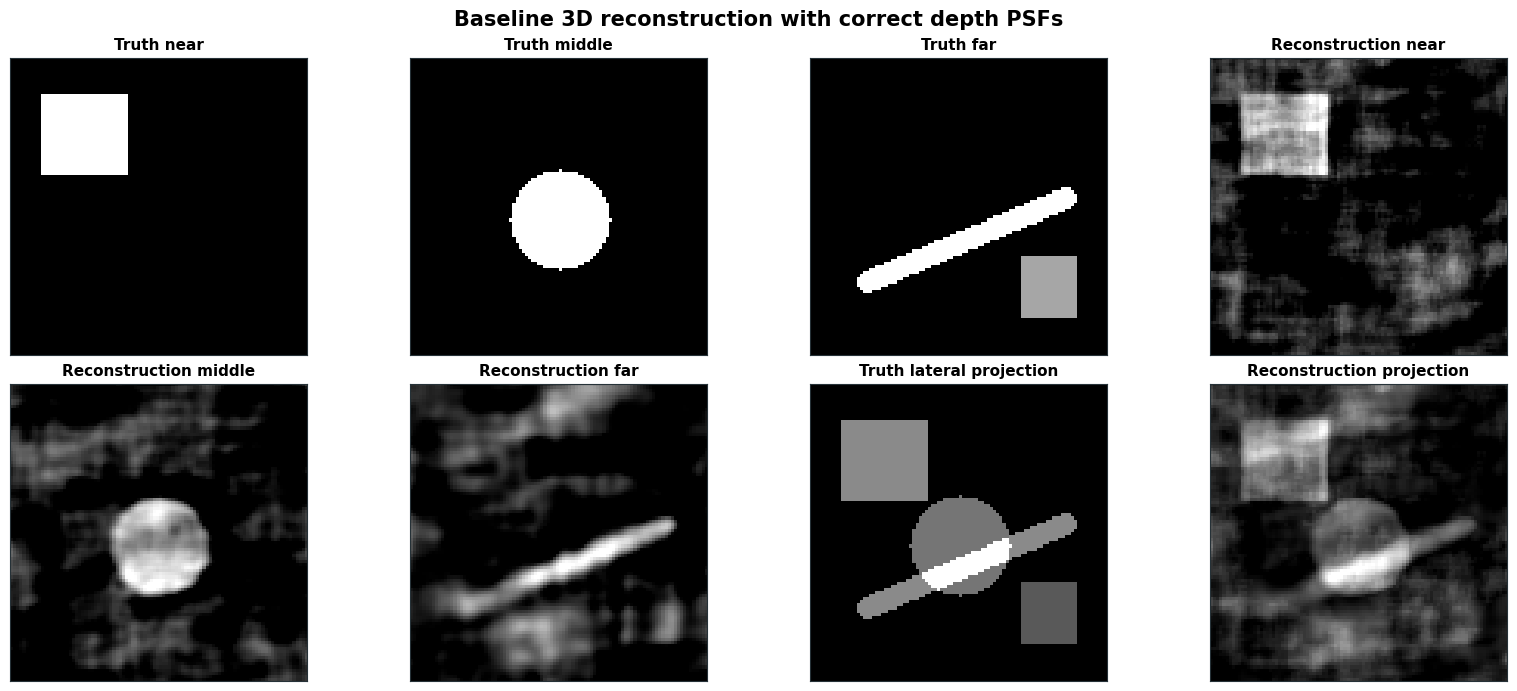

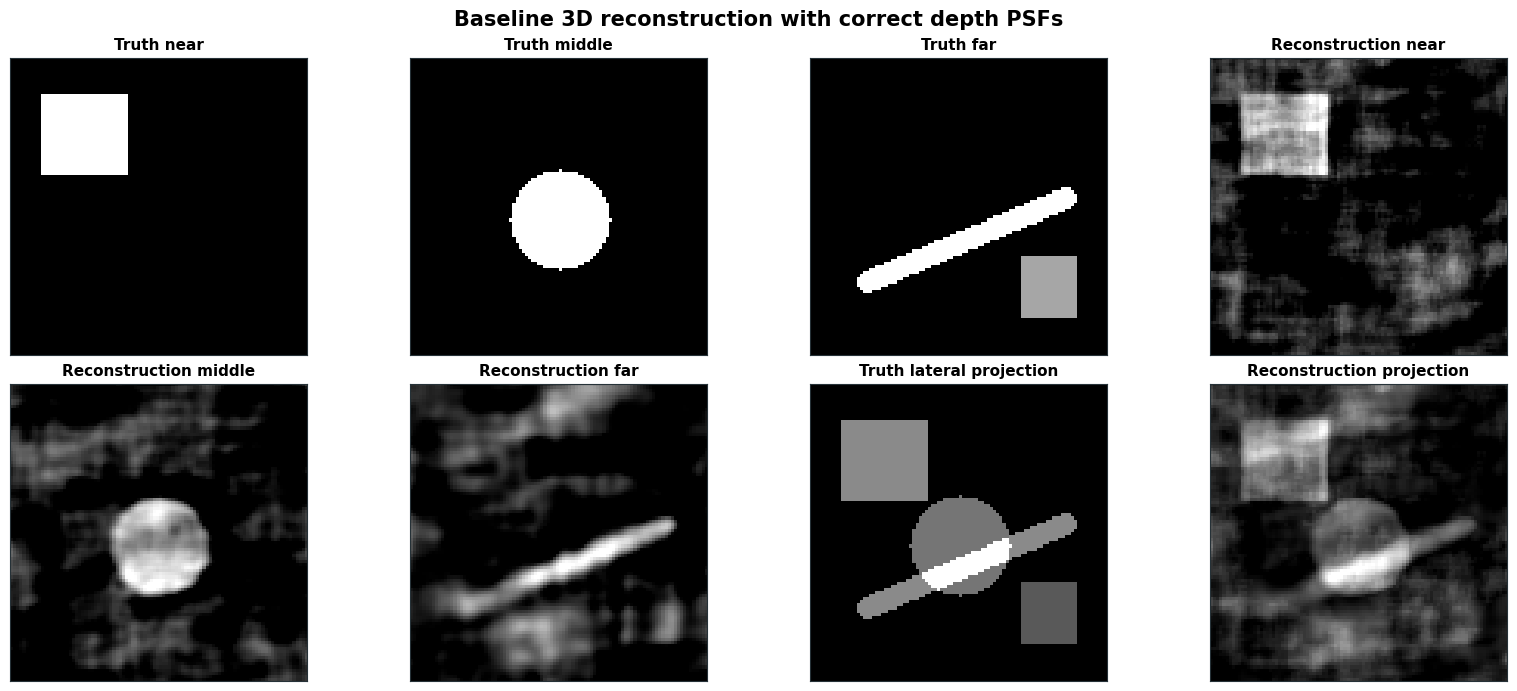

In [9]:
plot_image_grid(
    [(f'Truth {label}', truth_volume[index]) for index, label in enumerate(depth_labels)]
    + [(f'Reconstruction {label}', baseline_3d.volume[index]) for index, label in enumerate(depth_labels)]
    + [('Truth lateral projection', np.sum(truth_volume, axis=0)), ('Reconstruction projection', np.sum(baseline_3d.volume, axis=0))],
    RESULT_DIR / '04_baseline_3d_reconstruction.png',
    columns=4,
    title='Baseline 3D reconstruction with correct depth PSFs',
)

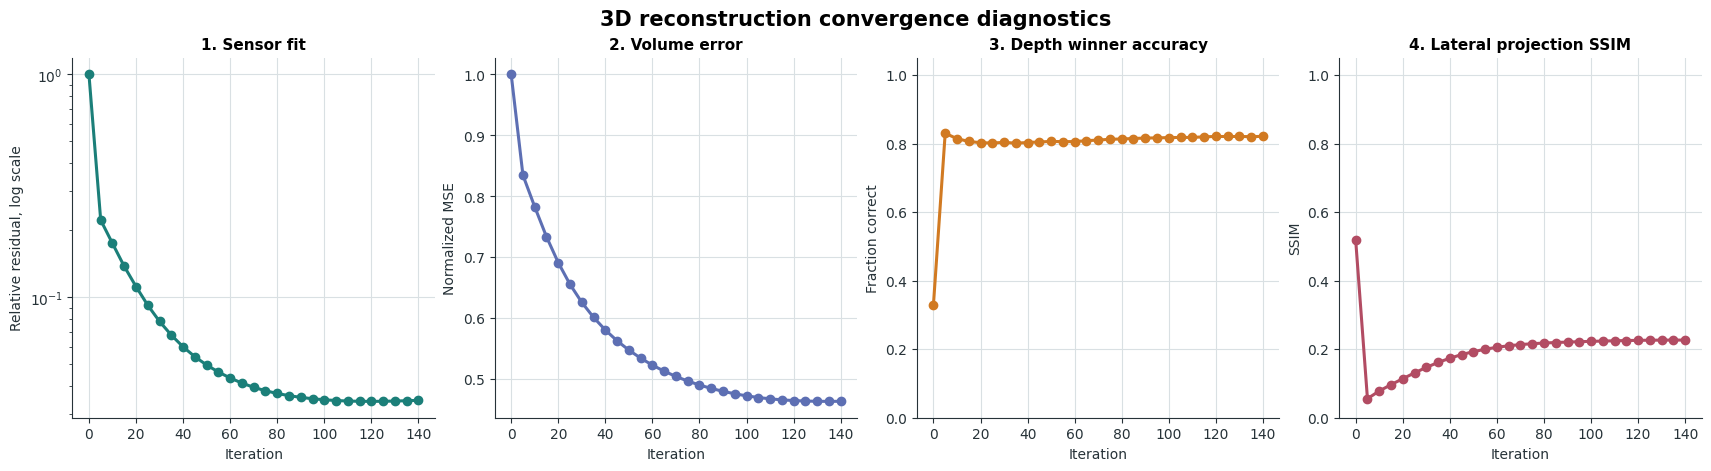

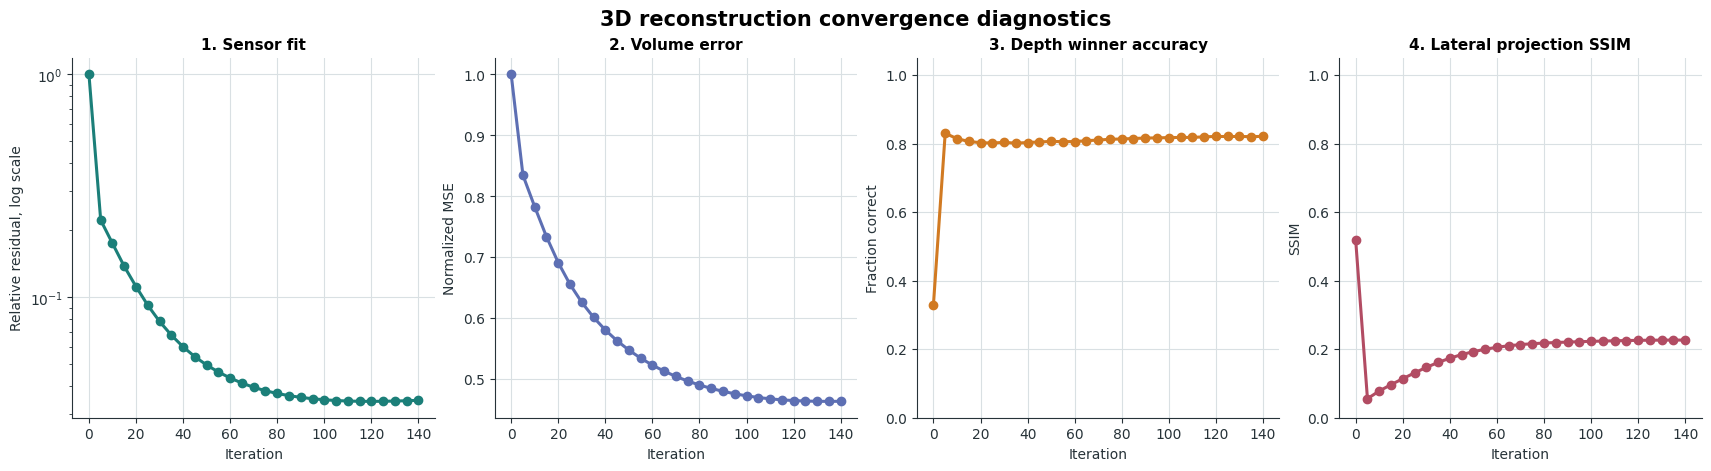

In [10]:
def plot_volume_convergence(result: VolumeReconstruction, path: Path):
    iterations = np.array([record.iteration for record in result.history])
    residual = np.array([record.relative_residual_l2 for record in result.history])
    nmse = np.array([record.volume_nmse for record in result.history])
    depth_accuracy = np.array([record.depth_accuracy for record in result.history])
    projection_ssim = np.array([record.projection_ssim for record in result.history])

    fig, axes = plt.subplots(1, 4, figsize=(17, 4.6), constrained_layout=True)
    fig.suptitle('3D reconstruction convergence diagnostics', fontsize=15, fontweight='bold')

    axes[0].plot(iterations, residual, marker='o', linewidth=2.2, color='#1b7f79')
    axes[0].set_yscale('log')
    axes[0].set_title('1. Sensor fit')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Relative residual, log scale')

    axes[1].plot(iterations, nmse, marker='o', linewidth=2.2, color='#5d6fb3')
    axes[1].set_title('2. Volume error')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Normalized MSE')

    axes[2].plot(iterations, depth_accuracy, marker='o', linewidth=2.2, color='#d17a22')
    axes[2].set_title('3. Depth winner accuracy')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Fraction correct')
    axes[2].set_ylim(0, 1.05)

    axes[3].plot(iterations, projection_ssim, marker='o', linewidth=2.2, color='#b24c63')
    axes[3].set_title('4. Lateral projection SSIM')
    axes[3].set_xlabel('Iteration')
    axes[3].set_ylabel('SSIM')
    axes[3].set_ylim(0, 1.05)

    for ax in axes:
        ax.grid(True, which='major')
        ax.spines[['top', 'right']].set_visible(False)

    return save_figure(fig, path)


plot_volume_convergence(baseline_3d, RESULT_DIR / '05_3d_convergence.png')

## 8. Depth Leakage Matrix

A 3D reconstruction can look reasonable laterally while putting energy at the wrong depth. To diagnose this, we compute a depth leakage matrix.

Entry \((i,j)\) means:

**For pixels whose true object belongs to depth \(i\), what fraction of reconstructed energy appears in depth \(j\)?**

An ideal reconstruction has a bright diagonal and dark off-diagonal entries.


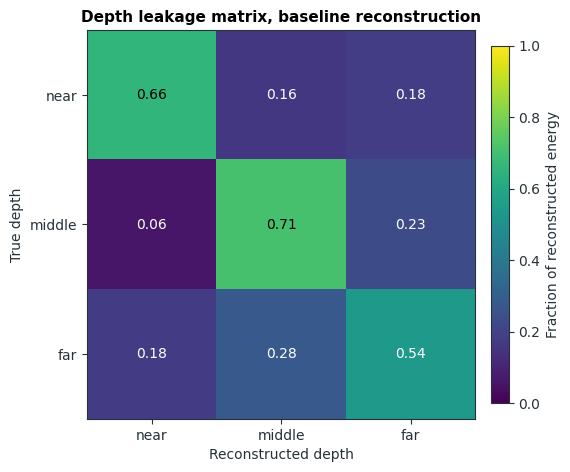

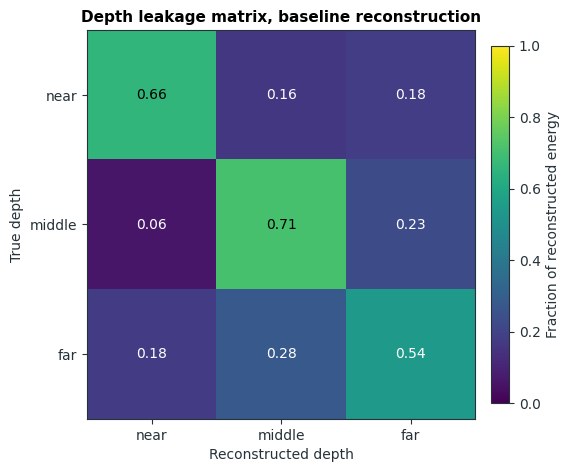

In [11]:
def depth_leakage_matrix(truth: np.ndarray, estimate: np.ndarray, masks: np.ndarray) -> np.ndarray:
    depth_count = truth.shape[0]
    leakage = np.zeros((depth_count, depth_count), dtype=np.float64)
    for true_depth in range(depth_count):
        support = masks[true_depth]
        energy_by_depth = np.array([float(np.sum(np.maximum(estimate[est_depth][support], 0.0))) for est_depth in range(depth_count)])
        leakage[true_depth] = energy_by_depth / max(float(np.sum(energy_by_depth)), 1e-12)
    return leakage


def plot_depth_leakage(leakage: np.ndarray, path: Path, title: str):
    fig, ax = plt.subplots(figsize=(5.6, 4.8), constrained_layout=True)
    im = ax.imshow(leakage, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Reconstructed depth')
    ax.set_ylabel('True depth')
    ax.set_xticks(np.arange(len(depth_labels)))
    ax.set_yticks(np.arange(len(depth_labels)))
    ax.set_xticklabels(depth_labels)
    ax.set_yticklabels(depth_labels)
    for row in range(leakage.shape[0]):
        for col in range(leakage.shape[1]):
            ax.text(col, row, f'{leakage[row, col]:.2f}', ha='center', va='center', color='white' if leakage[row, col] < 0.55 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Fraction of reconstructed energy')
    return save_figure(fig, path)


baseline_leakage = depth_leakage_matrix(truth_volume, baseline_3d.volume, depth_support_masks)
plot_depth_leakage(
    baseline_leakage,
    RESULT_DIR / '06_depth_leakage_matrix.png',
    title='Depth leakage matrix, baseline reconstruction',
)

## 9. Robustness: Noise, Regularization, and PSF Mismatch

Now we test the 3D model under controlled perturbations:

- lower noise: 45 dB,
- baseline noise: 35 dB,
- higher noise: 25 dB,
- shifted calibration PSFs,
- wrong depth order.

The wrong-depth-order case is intentionally severe: it asks what happens when calibration labels are swapped.


In [12]:
def shifted_operator_set(psfs: list[np.ndarray], row_shift: int, col_shift: int) -> list[PaddedLinearConvolution]:
    shifted_psfs = [normalize_sum(np.roll(np.roll(psf, row_shift, axis=0), col_shift, axis=1)) for psf in psfs]
    return [PaddedLinearConvolution(psf) for psf in shifted_psfs]


robustness_cases = []
for snr_db in [45, 35, 25]:
    case_measurement, _ = add_gaussian_noise_by_snr(clean_measurement, snr_db=snr_db, seed=20 + snr_db)
    robustness_cases.append((f'noise {snr_db} dB', operators, case_measurement))

robustness_cases.append(('PSFs shifted by 1 pixel', shifted_operator_set(psfs, 1, 1), measurement))
robustness_cases.append(('wrong depth order', list(reversed(operators)), measurement))

robustness_3d_results = []
for name, case_operators, case_measurement in robustness_cases:
    start = perf_counter()
    result = fista_volume(
        case_operators,
        case_measurement,
        iterations=90,
        truth=truth_volume,
        l2_regularization=2e-3,
        record_every=15,
    )
    seconds = perf_counter() - start
    final = result.history[-1]
    robustness_3d_results.append(
        {
            'case': name,
            'seconds': seconds,
            'result': result,
            'relative_residual_l2': final.relative_residual_l2,
            'volume_nmse': final.volume_nmse,
            'volume_psnr_db': final.volume_psnr_db,
            'projection_ssim': final.projection_ssim,
            'depth_accuracy': final.depth_accuracy,
        }
    )

robustness_3d_results

[{'case': 'noise 45 dB',
  'seconds': 1.7234644999844022,
  'result': VolumeReconstruction(volume=array([[[8.16357582e-02, 6.15923239e-02, 6.33685834e-02, ...,
           9.44189070e-02, 9.39225974e-02, 9.50462392e-02],
          [1.38051199e-01, 1.09714901e-01, 1.08492325e-01, ...,
           3.81422114e-02, 5.11195622e-02, 6.27272636e-02],
          [1.61933304e-01, 1.19854789e-01, 1.15978022e-01, ...,
           2.08406719e-02, 3.04085479e-02, 4.01076214e-02],
          ...,
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           5.01974183e-03, 5.52598195e-04, 3.53146828e-04],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           1.76260071e-03, 0.00000000e+00, 0.00000000e+00],
          [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           1.22353185e-03, 2.02256071e-05, 3.08620136e-02]],
  
         [[1.08800055e-01, 9.54374487e-02, 9.00349250e-02, ...,
           4.23345054e-02, 8.74196125e-02, 1.46475546e-01],
          [1.1197

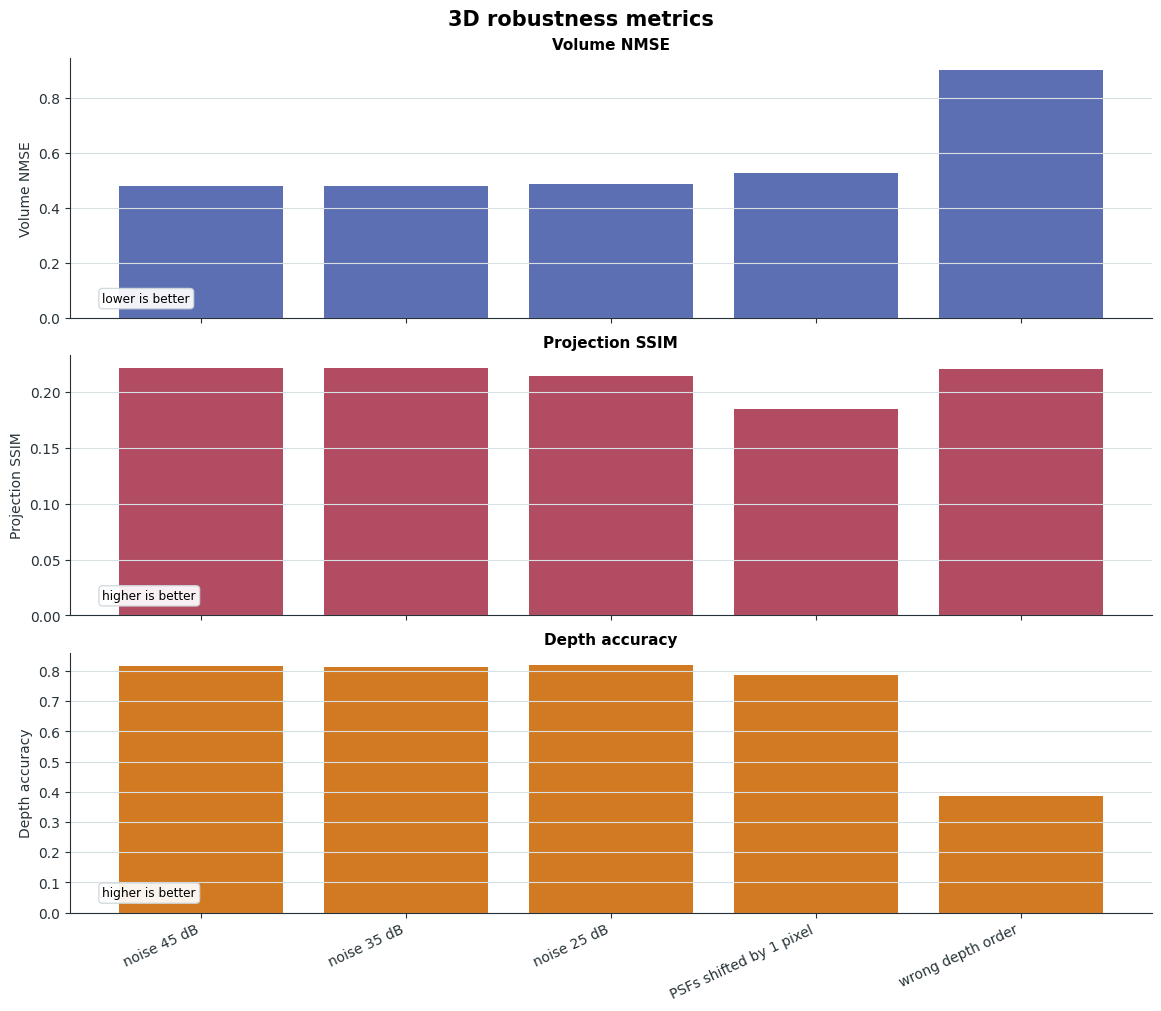

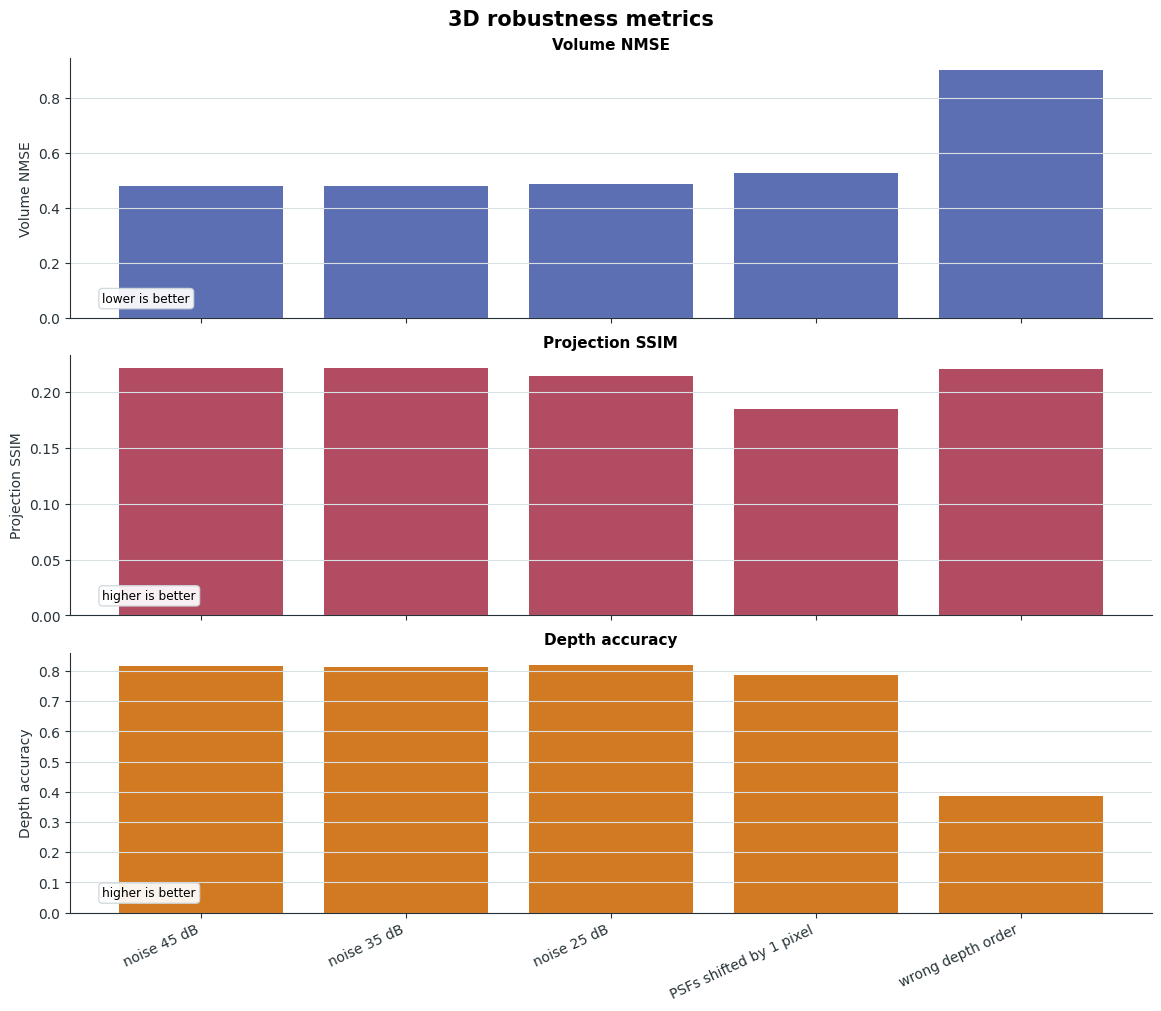

In [13]:
def plot_3d_robustness(results: list[dict], path: Path):
    names = [row['case'] for row in results]
    x = np.arange(len(names))
    metrics = [
        ('volume_nmse', 'Volume NMSE', '#5d6fb3', 'lower is better'),
        ('projection_ssim', 'Projection SSIM', '#b24c63', 'higher is better'),
        ('depth_accuracy', 'Depth accuracy', '#d17a22', 'higher is better'),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(11.5, 10), sharex=True, constrained_layout=True)
    fig.suptitle('3D robustness metrics', fontsize=15, fontweight='bold')
    for ax, (key, label, color, note) in zip(axes, metrics):
        values = [row[key] for row in results]
        ax.bar(x, values, color=color)
        ax.set_title(label)
        ax.set_ylabel(label)
        add_panel_note(ax, note)
        ax.grid(True, axis='y')
        ax.spines[['top', 'right']].set_visible(False)
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(names, rotation=25, ha='right')
    return save_figure(fig, path)


plot_3d_robustness(robustness_3d_results, RESULT_DIR / '07_3d_robustness_metrics.png')

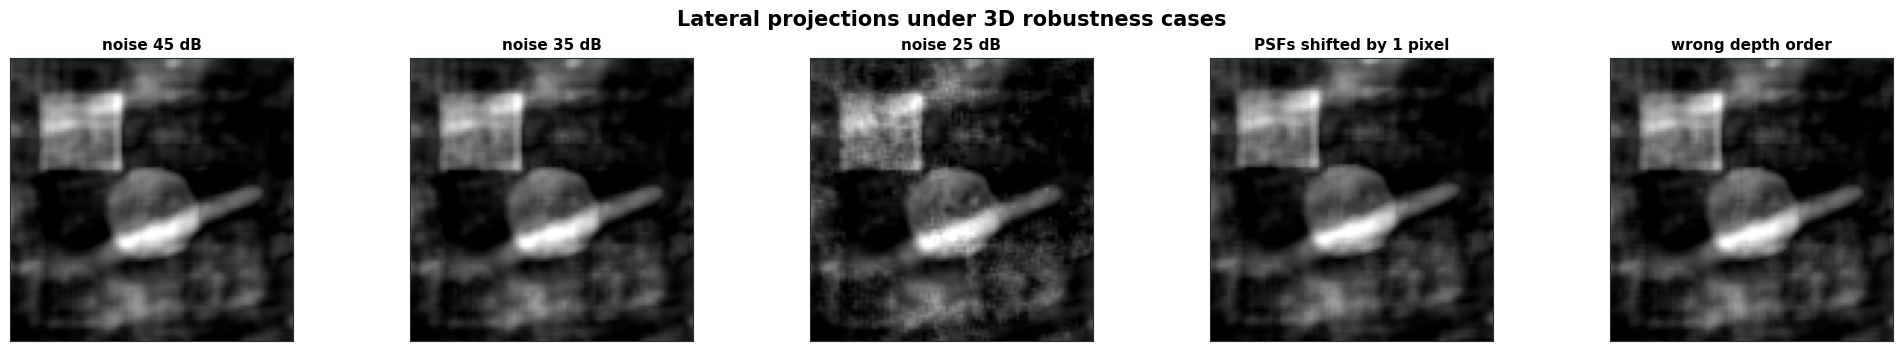

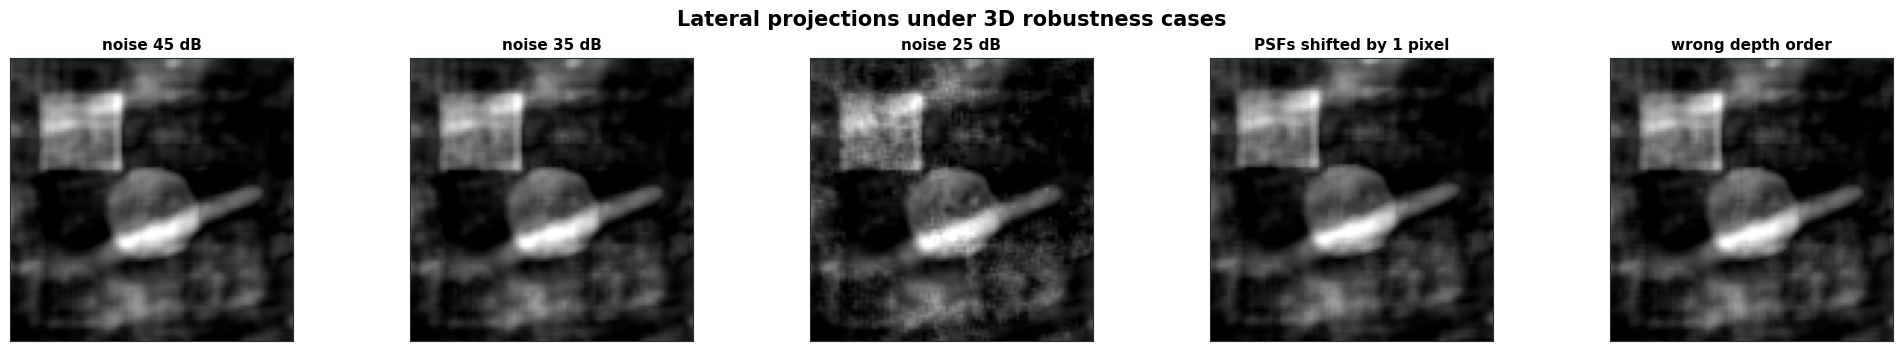

In [14]:
plot_image_grid(
    [(row['case'], np.sum(row['result'].volume, axis=0)) for row in robustness_3d_results],
    RESULT_DIR / '08_3d_robustness_projection_grid.png',
    columns=5,
    title='Lateral projections under 3D robustness cases',
)

## 10. What We Learned

The 3D model is a direct extension of the 2D model, but the inverse problem is much harder:

$$
b = \sum_z A_z x_z + n
$$

The sensor image is 2D, while the unknown object is 3D. Depth recovery therefore depends on the PSFs being sufficiently distinct and correctly calibrated.

Practical lessons:

- If depth PSFs are distinct, one measurement can contain recoverable depth information.
- Depth leakage is the key 3D failure mode.
- A good lateral image does not guarantee correct depth.
- PSF labeling and alignment matter: the wrong depth order can produce plausible-looking but physically wrong volumes.
- L2 and early stopping help, but stronger 3D priors will be needed for more realistic scenes.

Next natural upgrades:

1. Add 3D TV or lateral TV plus depth sparsity.
2. Add support constraints per depth.
3. Use measured depth-dependent PSFs when calibration data becomes available.
4. Move larger volume reconstruction to PyTorch/GPU.


In [15]:
summary = {
    'forward_info': forward_info,
    'baseline_summary': baseline_summary,
    'baseline_leakage': baseline_leakage.tolist(),
    'robustness_3d_results': [
        {
            'case': row['case'],
            'seconds': row['seconds'],
            'relative_residual_l2': row['relative_residual_l2'],
            'volume_nmse': row['volume_nmse'],
            'volume_psnr_db': row['volume_psnr_db'],
            'projection_ssim': row['projection_ssim'],
            'depth_accuracy': row['depth_accuracy'],
        }
        for row in robustness_3d_results
    ],
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

{
  "forward_info": {
    "measurement_shape": [
      96,
      96
    ],
    "snr_db": 35,
    "noise_sigma": 0.003170543075018259,
    "clean_measurement_max": 0.37374289751063283,
    "noisy_measurement_max": 0.37337263065772025
  },
  "baseline_summary": {
    "seconds": 2.8983801000285894,
    "step_size": 0.33311125916055956,
    "final_record": {
      "iteration": 140,
      "objective": 0.9308573303671296,
      "relative_residual_l2": 0.03453693814871349,
      "volume_nmse": 0.4639561585119848,
      "volume_psnr_db": 14.785363924006417,
      "projection_ssim": 0.22666645707393268,
      "depth_accuracy": 0.8213478064224333
    }
  },
  "baseline_leakage": [
    [
      0.656920526391097,
      0.1632074850135789,
      0.17987198859532405
    ],
    [
      0.0619208451811768,
      0.7075957325994577,
      0.2304834222193655
    ],
    [
      0.1781851743489542,
      0.2808496800224363,
      0.5409651456286094
    ]
  ],
  "robustness_3d_results": [
    {
      "case